# 03 - Modelado y comparación de modelos

En este notebook se entrenan y evalúan los modelos de detección de tráfico malicioso
utilizados en CyberSOC AI.

Se utilizará un modelo clásico supervisado como línea base y posteriormente un
modelo de Deep Learning basado en autoencoder.

El objetivo es comparar ambos enfoques utilizando criterios de evaluación
consistentes y justificar la selección del modelo más adecuado para el sistema.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_FILE = Path("../data/processed/cic_ids2017_clean.parquet")

df = pd.read_parquet(DATA_FILE)
print(f"Registros cargados: {len(df):,}")
print(f"Columnas cargadas: {len(df.columns)}")

Registros cargados: 2,520,798
Columnas cargadas: 80


## Preparación reproducible de los datos

Para evitar fugas de información (*data leakage*), las decisiones de
preprocesamiento y selección de características que dependan de los datos se
ajustan solamente utilizando el conjunto de entrenamiento.

El dataset se divide en entrenamiento (70 %), validación (10 %)
y prueba (20 %), manteniendo mediante estratificación la proporción entre
tráfico benigno y malicioso.

El conjunto de prueba se reserva para la evaluación final de
los modelos.

In [2]:
#Variables originales del dataset
original_features = [
    column for column in df.columns
    if column not in ["Label", "is_attack"]
]


X = df[original_features].copy()
y = df["is_attack"].copy()


#Primera división: 80 % desarrollo, 20 % test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#Segunda división: del 80 % se divide en 70 % train y 10 % validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.125,
    random_state=42,
    stratify=y_train_full
)


print(f"Variables originales: {len(original_features)}")
print(f"Entrenamiento: {len(X_train):,} ({len(X_train) / len(X) * 100:.1f} %)")
print(f"Validación:    {len(X_val):,} ({len(X_val) / len(X) * 100:.1f} %)")
print(f"Prueba:        {len(X_test):,} ({len(X_test) / len(X) * 100:.1f} %)")
print()
print("Distribución de clases:")
print(f"Train      → ataque: {y_train.mean() * 100:.2f} %")
print(f"Validation → ataque: {y_val.mean() * 100:.2f} %")
print(f"Test       → ataque: {y_test.mean() * 100:.2f} %")

Variables originales: 78
Entrenamiento: 1,764,558 (70.0 %)
Validación:    252,080 (10.0 %)
Prueba:        504,160 (20.0 %)

Distribución de clases:
Train      → ataque: 16.89 %
Validation → ataque: 16.89 %
Test       → ataque: 16.89 %


## Selección de características a partir del conjunto de entrenamiento

La selección de características se realiza utilizando el conjunto
de entrenamiento para evitar que información procedente de los conjuntos de
validación o prueba influya en la construcción del modelo.

Primero se eliminan las variables constantes porque no aportan capacidad
discriminativa. Después se analizará la correlación entre las variables
restantes para reducir la redundancia del conjunto de datos.

In [3]:
#Detectar constantes utilizando el conjunto de entrenamiento
unique_counts_train = X_train.nunique()
constant_columns = unique_counts_train[unique_counts_train <= 1].index.tolist()

print(f"Variables originales: {X_train.shape[1]}")
print(f"Variables constantes detectadas en train: {len(constant_columns)}")
print()

for column in constant_columns:
    print(f" - {column}")

Variables originales: 78
Variables constantes detectadas en train: 8

 - Bwd PSH Flags
 - Bwd URG Flags
 - Fwd Avg Bytes/Bulk
 - Fwd Avg Packets/Bulk
 - Fwd Avg Bulk Rate
 - Bwd Avg Bytes/Bulk
 - Bwd Avg Packets/Bulk
 - Bwd Avg Bulk Rate


In [4]:
#Eliminar las constantes a partir de train

X_train = X_train.drop(columns=constant_columns)
X_val = X_val.drop(columns=constant_columns)
X_test = X_test.drop(columns=constant_columns)

print(f"Variables en train:      {X_train.shape[1]}")
print(f"Variables en validation: {X_val.shape[1]}")
print(f"Variables en test:       {X_test.shape[1]}")

Variables en train:      70
Variables en validation: 70
Variables en test:       70


### Reducción de variables altamente correlacionadas

Tras eliminar las constantes, se analiza la correlación entre las
demás características utilizando el conjunto de entrenamiento.

Cuando dos variables presentan una correlación absoluta igual o superior a 0,95,
se considera que existe un elevado grado de redundancia. Para decidir cuál
conservar, se prioriza la que presenta mayor correlación absoluta con
la variable objetivo.

La selección resultante se aplicará a los
conjuntos de validación y prueba.

In [5]:
#Matriz de correlación calculada sólo con train
corr_matrix_train = X_train.corr().abs()

#Relación de cada característica con la variable objetivo calculada sólo con train
target_corr_train = (
    X_train
    .corrwith(y_train)
    .abs()
    .sort_values(ascending=False)
)


#Priorizar las características con mayor relación con el objetivo
ordered_features = target_corr_train.index.tolist()
selected_features = []

for feature in ordered_features:
    if not any(
        corr_matrix_train.loc[feature, selected] >= 0.95
        for selected in selected_features
    ):
        selected_features.append(feature)

removed_by_correlation = [
    feature for feature in X_train.columns
    if feature not in selected_features
]


print(f"Variables antes de reducir redundancia: {X_train.shape[1]}")
print(f"Variables eliminadas por alta correlación: {len(removed_by_correlation)}")
print(f"Variables seleccionadas: {len(selected_features)}")
print()
print("Variables eliminadas:")
for feature in removed_by_correlation:
    print(f" - {feature}")

Variables antes de reducir redundancia: 70
Variables eliminadas por alta correlación: 22
Variables seleccionadas: 48

Variables eliminadas:
 - Flow Duration
 - Total Fwd Packets
 - Total Length of Fwd Packets
 - Total Length of Bwd Packets
 - Fwd Packet Length Std
 - Bwd Packet Length Max
 - Flow Packets/s
 - Flow IAT Max
 - Fwd IAT Max
 - Max Packet Length
 - Packet Length Mean
 - SYN Flag Count
 - RST Flag Count
 - CWE Flag Count
 - Avg Fwd Segment Size
 - Avg Bwd Segment Size
 - Fwd Header Length.1
 - Subflow Fwd Packets
 - Subflow Bwd Packets
 - Subflow Bwd Bytes
 - Idle Mean
 - Idle Min


In [6]:
#Aplicar a los tres conjuntos la selección aprendida con train

X_train = X_train[selected_features].copy()
X_val = X_val[selected_features].copy()
X_test = X_test[selected_features].copy()

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print()
print(f"Variables seleccionadas: {len(selected_features)}")

Train:      (1764558, 48)
Validation: (252080, 48)
Test:       (504160, 48)

Variables seleccionadas: 48


## Modelo baseline: Random Forest

Se utiliza Random Forest como modelo supervisado de referencia para establecer
una línea base de rendimiento frente al posterior modelo de Deep Learning.

Random Forest es adecuado para datos tabulares y permite modelar relaciones
no lineales entre las características. Además, al estar basado en árboles de
decisión, no requiere el previo escalado de las variables.

El modelo se entrena utilizando tanto tráfico benigno como malicioso y sus
correspondientes etiquetas.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [8]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [9]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print(random_forest)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


### Entrenamiento del modelo

El modelo Random Forest se entrena sobre el conjunto de entrenamiento utilizando
las 48 características seleccionadas. Además se registra el tiempo de
entrenamiento para poder compararlo posteriormente con el modelo de Deep Learning.

In [10]:
import time

start_time = time.time()
random_forest.fit(X_train, y_train)
training_time_rf = time.time() - start_time

print("Entrenamiento completado.")
print(f"Tiempo de entrenamiento: {training_time_rf:.2f} segundos")
print(f"Árboles entrenados: {len(random_forest.estimators_)}")

Entrenamiento completado.
Tiempo de entrenamiento: 191.65 segundos
Árboles entrenados: 100


### Evaluación sobre el conjunto de validación

El modelo se evalúa en un principio sobre el conjunto de validación, que no ha
sido utilizado durante el entrenamiento.

Esta evaluación permite analizar su capacidad de generalización y servirá
como referencia para comparar posteriormente el modelo clásico con el
autoencoder, sin utilizar todavía el conjunto de prueba, reservado para la
evaluación final.

In [11]:
start_time = time.time()

y_val_pred_rf = random_forest.predict(X_val)

prediction_time_rf = time.time() - start_time

accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
f1_rf = f1_score(y_val, y_val_pred_rf)

print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print()
print(f"Tiempo de predicción: {prediction_time_rf:.2f} segundos")

Accuracy:  0.9990
Precision: 0.9957
Recall:    0.9983
F1-score:  0.9970

Tiempo de predicción: 0.81 segundos


### Matriz de confusión

La matriz de confusión permite analizar los aciertos y errores del modelo en
términos absolutos, distinguiendo entre tráfico benigno y malicioso.

En un sistema de detección de amenazas resulta muy importante analizar
los falsos negativos, ya que representan ataques reales que el modelo no ha
conseguido detectar.

In [12]:
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

print("Matriz de confusión:")
print(cm_rf)
print()
print(f"Verdaderos negativos (benignos correctamente identificados): {tn:,}")
print(f"Falsos positivos (benignos marcados como ataque):             {fp:,}")
print(f"Falsos negativos (ataques no detectados):                     {fn:,}")
print(f"Verdaderos positivos (ataques detectados):                    {tp:,}")

Matriz de confusión:
[[209324    182]
 [    71  42503]]

Verdaderos negativos (benignos correctamente identificados): 209,324
Falsos positivos (benignos marcados como ataque):             182
Falsos negativos (ataques no detectados):                     71
Verdaderos positivos (ataques detectados):                    42,503


### Análisis de falsos negativos por tipo de ataque

Además de las métricas globales, se analiza qué tipos de ataque no
son detectados por el modelo.

Este análisis resulta relevante debido al gran desequilibrio
que existe entre las distintas categorías de ataque del dataset. Un buen
rendimiento global podría ocultar un comportamiento deficiente sobre ataques
minoritarios.

In [13]:
#Recuperar el tipo concreto de tráfico de cada registro de validación
val_labels = df.loc[y_val.index, "Label"]

#DataFrame para analizar conjuntamente etiqueta real, predicción y tipo de ataque
validation_results_rf = pd.DataFrame({
    "y_real": y_val,
    "y_pred": y_val_pred_rf,
    "Label": val_labels
})

#Seleccionar sólo los ataques reales
attack_results_rf = validation_results_rf[
    validation_results_rf["y_real"] == 1
].copy()

#Resumen por tipo de ataque
attack_analysis_rf = (
    attack_results_rf
    .groupby("Label")
    .agg(
        ataques_reales=("y_real", "size"),
        detectados=("y_pred", "sum")
    )
)

attack_analysis_rf["no_detectados"] = (
    attack_analysis_rf["ataques_reales"]
    - attack_analysis_rf["detectados"]
)

attack_analysis_rf["recall"] = (
    attack_analysis_rf["detectados"]
    / attack_analysis_rf["ataques_reales"]
)

attack_analysis_rf = attack_analysis_rf.sort_values(
    ["recall", "ataques_reales"],
    ascending=[True, False]
)

print(attack_analysis_rf.to_string())

                          ataques_reales  detectados  no_detectados    recall
Label                                                                        
Infiltration                           2           1              1  0.500000
Bot                                  169         144             25  0.852071
PortScan                            9066        9047             19  0.997904
DoS slowloris                        563         562              1  0.998224
DoS Hulk                           17211       17192             19  0.998896
DDoS                               12810       12804              6  0.999532
DoS GoldenEye                       1057        1057              0  1.000000
FTP-Patator                          596         596              0  1.000000
DoS Slowhttptest                     563         563              0  1.000000
SSH-Patator                          325         325              0  1.000000
Web Attack � Brute Force             142         142            

### Rendimiento por tipo de ataque

El elevado rendimiento global del modelo no es uniforme entre todas las
categorías de ataque. Por ello, se analiza el recall obtenido para cada tipo
de amenaza del conjunto de validación.

Este análisis permite detectar posibles limitaciones asociadas al
desequilibrio que existe entre las distintas categorías del dataset.

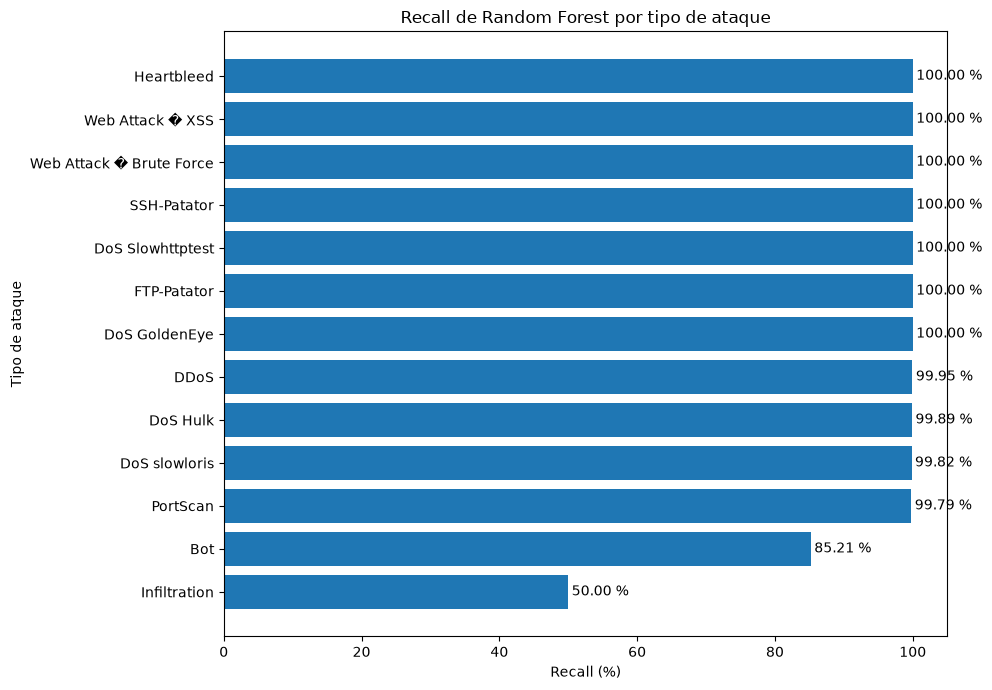

In [14]:
attack_plot_rf = attack_analysis_rf.sort_values("recall")

plt.figure(figsize=(10, 7))

bars = plt.barh(
    attack_plot_rf.index,
    attack_plot_rf["recall"] * 100
)

plt.xlabel("Recall (%)")
plt.ylabel("Tipo de ataque")
plt.title("Recall de Random Forest por tipo de ataque")
plt.xlim(0, 105)

for bar, value in zip(bars, attack_plot_rf["recall"] * 100):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f} %",
        va="center"
    )

plt.tight_layout()
plt.show()

### Conclusiones del modelo baseline

El modelo Random Forest obtiene un rendimiento muy elevado en la detección
binaria de tráfico malicioso, alcanzando un recall global superior al 99 %.

Sin embargo, el análisis individual por tipo de ataque muestra que el
rendimiento no es homogéneo para todas las amenazas. Las categorías con mayor
representación en el dataset presentan tasas de detección cercanas al 100 %,
mientras que algunas clases minoritarias muestran resultados inferiores.

En este sentido destaca la categoría Bot, cuyo recall es inferior al de las
principales categorías de ataque. En el caso de Infiltration, el reducido
número de muestras presentes en el conjunto de validación impide obtener
conclusiones estadísticamente representativas.

Estos resultados exponen la importancia de no evaluar un sistema
de detección de intrusiones sólo mediante métricas globales y justifican
la exploración de técnicas de detección de anomalías capaces de identificar
comportamientos diferentes del tráfico considerado normal.